Let's check if the conductance of random lattices is similar or different. (Seed dependence)

In [ ]:
%load_ext autoreload
%autoreload 2
import kwant
import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from koala.lattice import Lattice
from alter_morph.hamiltonians import alt_hamiltonian
from alter_morph.lattice_utilities import alter_lattice_maker,add_contacts
from alter_morph.mean_field import hartree_fock
from alter_morph.kwant_utilities import Amorphous



# plotting
import matplotlib
import matplotlib.pyplot as plt

import koala.graph_utils


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
# create lattice
system_length = 20
seeds = 40
lattice_type = "voronoi"

lattices = []

for j in range(seeds):
    lattice = alter_lattice_maker(system_length, lattice_type)
    lattice = koala.graph_utils.cut_boundaries(lattice, [False, True])
    lattices.append(lattice)

# set parameters, scan different values of J
t1 = 1  # orbital parallel neighbor hopping
t2 = 0.5  # orbital perpendicular neighbor hopping
J = 0  # Interaction strength
filling = 0.2  # filling of the lattice

/var/folders/xb/6hhfs1vn32s_g5b9xk9fx8yh0000gn/T/ipykernel_65740/3134954163.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  im = ax.scatter(


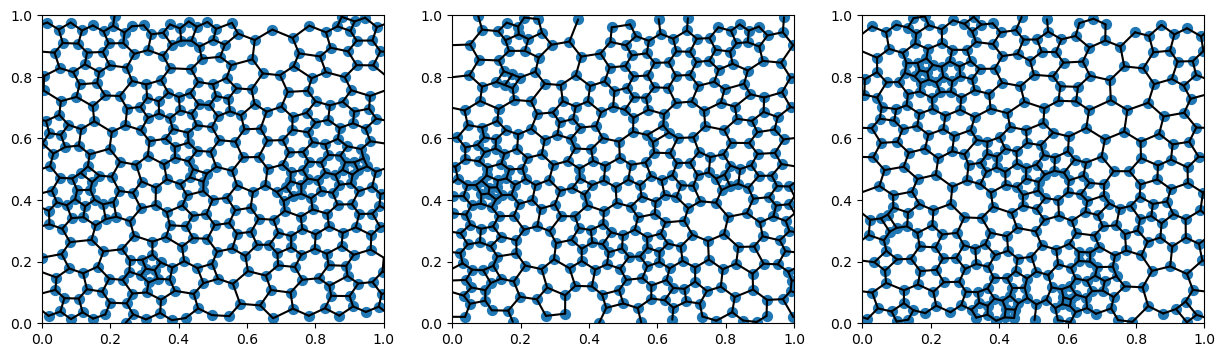

In [25]:
fig, axs = plt.subplots(1, seeds, figsize=(5*seeds, 4))
for j in range(seeds):
    ax = axs[j]
    pl.plot_edges(lattices[j], ax=ax)
    im = ax.scatter(
        lattices[j].vertices.positions[:, 0],
        lattices[j].vertices.positions[:, 1],
        cmap="gist_stern_r",
        s=50,
        vmin=0,
        vmax=2,
    )

In [38]:
from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)

conds = []

for j in range(seeds):
    lattice = lattices[j]
    hamiltonian = alt_hamiltonian(
        lattice,
        t1,
        t2,
        J,
        np.zeros(lattice.n_vertices),
    )

    n_orbitals = 4
    lead_onsite = np.eye(n_orbitals)
    lead_coupling = np.eye(n_orbitals)

    contact_lattice, k_lattice, k_system, contact_vertices = (
        crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
    )
    kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
        contact_lattice, k_lattice, k_system, contact_vertices, lead_onsite, lead_coupling, np.diag([-1,-1,1,1])
    )

    k_system_f = k_system.finalized()
    smatrix = kwant.smatrix(k_system_f)
    g = np.array([[smatrix.transmission((1,j),(0,i)) for j in range(2)] for i in range(2)])
    
    conds.append(g[0,0]+g[1,1])

conds = np.array(conds)

4.696065239072363 0.6083131944366442


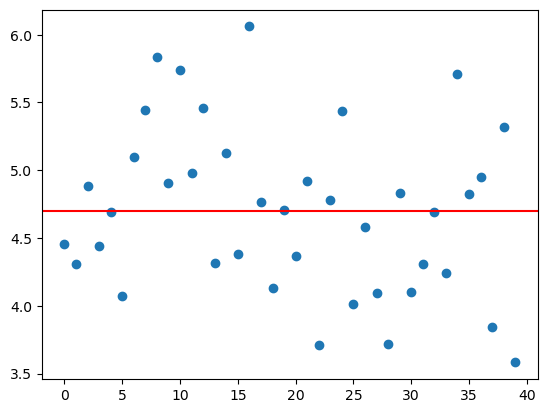

In [39]:
plt.plot(conds, "o")
plt.axhline(conds.mean(), color="red")

print(conds.mean(), conds.std())